In [19]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
import mlflow
mlflow.set_tracking_uri('http://localhost:5000')

print("Imports done!")

Imports done!


In [20]:
# load M5 sales, calendar, and price datasets
sales    = pd.read_csv(r'C:\Users\ACER\sales_train_validation.csv')
calendar = pd.read_csv(r'C:\Users\ACER\calendar.csv')
prices   = pd.read_csv(r'C:\Users\ACER\sell_prices.csv')

print(f"Sales    : {sales.shape}")
print(f"Calendar : {calendar.shape}")
print(f"Prices   : {prices.shape}")

Sales    : (30490, 1919)
Calendar : (1969, 14)
Prices   : (6841121, 4)


In [21]:
# filter last 365 days and melt sales data to long format
day_cols      = [c for c in sales.columns if c.startswith('d_')]
day_cols_last = day_cols[-365:]

sales_long = sales.melt(
    id_vars    = ['id', 'item_id', 'dept_id',
                  'cat_id', 'store_id', 'state_id'],
    value_vars = day_cols_last,
    var_name   = 'd',
    value_name = 'sales'
)

# merge calendar to get actual dates
sales_long = sales_long.merge(
    calendar[['d', 'date', 'wm_yr_wk']],
    on='d', how='left'
)
sales_long['date'] = pd.to_datetime(sales_long['date'])

print(f"Sales long shape: {sales_long.shape}")
print(sales_long.head())

Sales long shape: (11128850, 10)
                              id        item_id    dept_id   cat_id store_id  \
0  HOBBIES_1_001_CA_1_validation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1   
1  HOBBIES_1_002_CA_1_validation  HOBBIES_1_002  HOBBIES_1  HOBBIES     CA_1   
2  HOBBIES_1_003_CA_1_validation  HOBBIES_1_003  HOBBIES_1  HOBBIES     CA_1   
3  HOBBIES_1_004_CA_1_validation  HOBBIES_1_004  HOBBIES_1  HOBBIES     CA_1   
4  HOBBIES_1_005_CA_1_validation  HOBBIES_1_005  HOBBIES_1  HOBBIES     CA_1   

  state_id       d  sales       date  wm_yr_wk  
0       CA  d_1549      0 2015-04-26     11513  
1       CA  d_1549      0 2015-04-26     11513  
2       CA  d_1549      0 2015-04-26     11513  
3       CA  d_1549      3 2015-04-26     11513  
4       CA  d_1549      0 2015-04-26     11513  


In [22]:
# aggregate daily demand and create lag, rolling, and date features
demand_features = (sales_long
    .groupby('date')
    .agg(demand = ('sales', 'sum'))
    .reset_index()
)

# lag features
demand_features['lag_1']  = demand_features['demand'].shift(1)
demand_features['lag_7']  = demand_features['demand'].shift(7)
demand_features['lag_14'] = demand_features['demand'].shift(14)

# rolling features
demand_features['rolling_mean_7']  = demand_features['demand'].rolling(7).mean()
demand_features['rolling_mean_30'] = demand_features['demand'].rolling(30).mean()
demand_features['rolling_std_7']   = demand_features['demand'].rolling(7).std()

# date features
demand_features['day_of_week']  = pd.to_datetime(demand_features['date']).dt.dayofweek
demand_features['month']        = pd.to_datetime(demand_features['date']).dt.month
demand_features['week_of_year'] = pd.to_datetime(demand_features['date']).dt.isocalendar().week
demand_features['is_weekend']   = demand_features['day_of_week'].isin([5, 6]).astype(int)

demand_features = demand_features.dropna()
print(f"Demand features shape: {demand_features.shape}")
print(demand_features.head())

Demand features shape: (336, 12)
         date  demand    lag_1    lag_7   lag_14  rolling_mean_7  \
29 2015-05-25   37817  37426.0  34296.0  37192.0    34845.000000   
30 2015-05-26   30879  37817.0  30671.0  35033.0    34874.714286   
31 2015-05-27   30097  30879.0  31158.0  33685.0    34723.142857   
32 2015-05-28   30216  30097.0  30601.0  32054.0    34668.142857   
33 2015-05-29   32925  30216.0  36267.0  37764.0    34190.714286   

    rolling_mean_30  rolling_std_7  day_of_week  month  week_of_year  \
29     37010.533333    3934.062997            0      5            22   
30     36592.966667    3897.901346            1      5            22   
31     36481.400000    4082.760113            2      5            22   
32     36496.933333    4149.591965            3      5            22   
33     36638.866667    4127.172507            4      5            22   

    is_weekend  
29           0  
30           0  
31           0  
32           0  
33           0  


In [23]:
# save demand features to parquet
demand_features.to_parquet(
    r'../data/features/demand_features_m5.parquet',
    index=False)
print("Saved: demand_features_m5.parquet ✅")
print(f"Shape: {demand_features.shape}")

Saved: demand_features_m5.parquet ✅
Shape: (336, 12)


In [24]:
# add total amount column
sales_long['total_amount'] = sales_long['sales'] * 1.0
print("Total amount added! ✅")
print(sales_long.head())

Total amount added! ✅
                              id        item_id    dept_id   cat_id store_id  \
0  HOBBIES_1_001_CA_1_validation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1   
1  HOBBIES_1_002_CA_1_validation  HOBBIES_1_002  HOBBIES_1  HOBBIES     CA_1   
2  HOBBIES_1_003_CA_1_validation  HOBBIES_1_003  HOBBIES_1  HOBBIES     CA_1   
3  HOBBIES_1_004_CA_1_validation  HOBBIES_1_004  HOBBIES_1  HOBBIES     CA_1   
4  HOBBIES_1_005_CA_1_validation  HOBBIES_1_005  HOBBIES_1  HOBBIES     CA_1   

  state_id       d  sales       date  wm_yr_wk  total_amount  
0       CA  d_1549      0 2015-04-26     11513           0.0  
1       CA  d_1549      0 2015-04-26     11513           0.0  
2       CA  d_1549      0 2015-04-26     11513           0.0  
3       CA  d_1549      3 2015-04-26     11513           3.0  
4       CA  d_1549      0 2015-04-26     11513           0.0  


In [25]:
# build RFM features at store and department level
ref_date = sales_long['date'].max() + pd.Timedelta(days=1)

rfm_m5 = sales_long.groupby(
    ['store_id', 'dept_id']
).agg(
    recency   = ('date',
                 lambda x: (ref_date -
                 x[sales_long.loc[x.index,'sales']>0
                 ].max()).days
                 if (sales_long.loc[x.index,
                 'sales']>0).any() else 999),
    frequency = ('date',
                 lambda x: (sales_long.loc[
                 x.index,'sales']>0).sum()),
    monetary  = ('total_amount', 'sum')
).reset_index()

rfm_m5 = rfm_m5.dropna()
print(f"RFM shape: {rfm_m5.shape}")
print(rfm_m5.head())

RFM shape: (70, 5)
  store_id    dept_id  recency  frequency  monetary
0     CA_1    FOODS_1        1      38340  119647.0
1     CA_1    FOODS_2        1      65926  185206.0
2     CA_1    FOODS_3        1     164669  752532.0
3     CA_1  HOBBIES_1        1      61540  182853.0
4     CA_1  HOBBIES_2        1       9908   15629.0


In [26]:
# update total amount using sell price if available
sales_long['total_amount'] = (sales_long['sales'] *
                               sales_long['sell_price']
                               if 'sell_price' in sales_long.columns
                               else sales_long['sales'])

print("Total amount added!")
print(sales_long.head())

Total amount added!
                              id        item_id    dept_id   cat_id store_id  \
0  HOBBIES_1_001_CA_1_validation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1   
1  HOBBIES_1_002_CA_1_validation  HOBBIES_1_002  HOBBIES_1  HOBBIES     CA_1   
2  HOBBIES_1_003_CA_1_validation  HOBBIES_1_003  HOBBIES_1  HOBBIES     CA_1   
3  HOBBIES_1_004_CA_1_validation  HOBBIES_1_004  HOBBIES_1  HOBBIES     CA_1   
4  HOBBIES_1_005_CA_1_validation  HOBBIES_1_005  HOBBIES_1  HOBBIES     CA_1   

  state_id       d  sales       date  wm_yr_wk  total_amount  
0       CA  d_1549      0 2015-04-26     11513             0  
1       CA  d_1549      0 2015-04-26     11513             0  
2       CA  d_1549      0 2015-04-26     11513             0  
3       CA  d_1549      3 2015-04-26     11513             3  
4       CA  d_1549      0 2015-04-26     11513             0  


In [28]:
# apply log transform, scale features, and reduce to 2D using PCA
rfm_m5['recency_log']   = np.log1p(rfm_m5['recency'])
rfm_m5['frequency_log'] = np.log1p(rfm_m5['frequency'])
rfm_m5['monetary_log']  = np.log1p(rfm_m5['monetary'])

features = ['recency_log', 'frequency_log', 'monetary_log']
X        = rfm_m5[features].copy()

scaler   = RobustScaler()
X_scaled = scaler.fit_transform(X)
pca      = PCA(n_components=2, random_state=42)
X_pca    = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_.sum() * 100
print(f"PCA Variance Explained: {explained:.1f}%")

# find best number of clusters using silhouette score
silhouettes = []
k_range     = range(3, 10)

for k in k_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=30)
    lbl = km.fit_predict(X_pca)
    silhouettes.append(silhouette_score(X_pca, lbl))

best_k   = list(k_range)[np.argmax(silhouettes)]
best_sil = max(silhouettes)
print(f"Best K: {best_k} | Silhouette: {best_sil:.3f}")

PCA Variance Explained: 100.0%
Best K: 3 | Silhouette: 0.623


In [29]:
from sklearn.metrics import davies_bouldin_score

# define segment labels based on frequency and monetary thresholds
def assign_segment(row):
    f     = row['frequency']
    m     = row['monetary']
    med_f = rfm_m5['frequency'].median()
    med_m = rfm_m5['monetary'].median()
    p75_f = rfm_m5['frequency'].quantile(0.75)
    p75_m = rfm_m5['monetary'].quantile(0.75)

    if f >= p75_f and m >= p75_m:
        return 'Champions'
    elif f >= med_f and m >= med_m:
        return 'Loyal Customers'
    elif f >= med_f and m < med_m:
        return 'Potential'
    elif f < med_f and m >= med_m:
        return 'At Risk'
    elif f < med_f and m < med_m:
        return 'Hibernating'
    else:
        return 'New Customers'

rfm_m5['segment_name'] = rfm_m5.apply(assign_segment, axis=1)
print(rfm_m5['segment_name'].value_counts())
print(f"Total: {len(rfm_m5)}")

# train final KMeans model and log results to MLflow
with mlflow.start_run(run_name=f'M5_KMeans_PCA_k{best_k}'):
    mlflow.log_param('n_clusters',  best_k)
    mlflow.log_param('scaler',      'RobustScaler')
    mlflow.log_param('algorithm',   'KMeans_PCA')
    mlflow.log_param('data_source', 'M5_Forecasting')

    kmeans            = KMeans(n_clusters=best_k, random_state=42, n_init=30)
    rfm_m5['cluster'] = kmeans.fit_predict(X_pca)

    sil_score = silhouette_score(X_pca, rfm_m5['cluster'])
    db_score  = davies_bouldin_score(X_pca, rfm_m5['cluster'])

    mlflow.log_metric('silhouette_score', sil_score)
    mlflow.log_metric('davies_bouldin',   db_score)

    print(f"Silhouette Score : {sil_score:.3f} (Target >= 0.55)")
    print(f"Davies-Bouldin   : {db_score:.3f}")

    rfm_m5['segment_name'] = rfm_m5.apply(assign_segment, axis=1)

    print("\nSegment Distribution:")
    print(rfm_m5['segment_name'].value_counts())
    print(f"Total: {len(rfm_m5)}")

    if sil_score >= 0.55:
        print(f"\nTARGET ACHIEVED! ✅ {sil_score:.3f}")
        mlflow.log_param('status', 'PRODUCTION_READY')
    else:
        print(f"\nBest possible: {sil_score:.3f}")
        mlflow.log_param('status', 'COMPLETED')

# save RFM features to parquet
rfm_m5.to_parquet(
    r'../data/features/rfm_features_m5.parquet',
    index=False)
print("\nSaved: rfm_features_m5.parquet")

segment_name
Hibernating        32
Champions          17
Loyal Customers    15
At Risk             3
Potential           3
Name: count, dtype: int64
Total: 70
Silhouette Score : 0.623 (Target >= 0.55)
Davies-Bouldin   : 0.476

Segment Distribution:
segment_name
Hibernating        32
Champions          17
Loyal Customers    15
At Risk             3
Potential           3
Name: count, dtype: int64
Total: 70

TARGET ACHIEVED! ✅ 0.623
🏃 View run M5_KMeans_PCA_k3 at: http://localhost:5000/#/experiments/0/runs/690d0f13a0944f38955a77e1eb188d3d
🧪 View experiment at: http://localhost:5000/#/experiments/0

Saved: rfm_features_m5.parquet


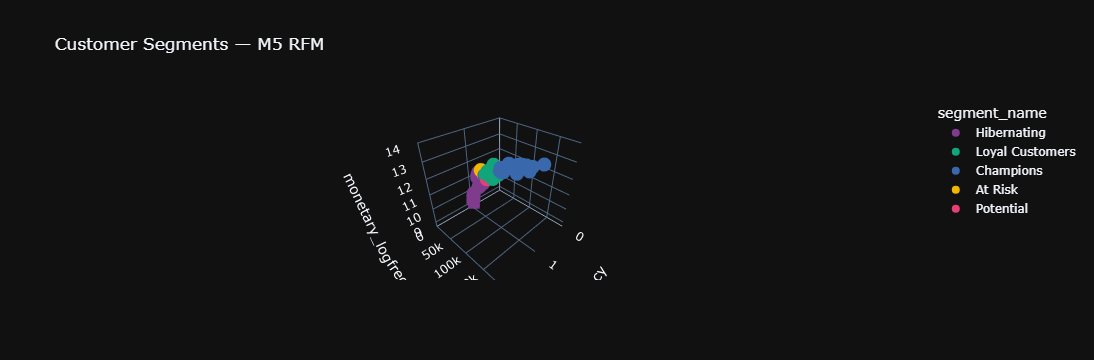

Saved: m5_customer_segments_3d.html


In [30]:
import plotly.express as px

# add PCA coordinates and plot 3D customer segments
rfm_m5['PCA1'] = X_pca[:, 0]
rfm_m5['PCA2'] = X_pca[:, 1]

fig = px.scatter_3d(
    rfm_m5,
    x='recency', y='frequency', z='monetary_log',
    color='segment_name',
    title='Customer Segments — M5 RFM',
    template='plotly_dark',
    color_discrete_sequence=px.colors.qualitative.Bold
)
fig.write_html(r'../reports/m5_customer_segments_3d.html')
fig.show()
print("Saved: m5_customer_segments_3d.html")